In [1]:
import pandas as pd
import numpy as np
import requests
import time
import math
import matplotlib.pyplot as plt
from pyproj import Transformer

In [2]:
path_folder = "Datasets/"
path_claim_optClean = "ds_claim_optClean.xlsx"

In [3]:
ds_claim_optClean = pd.read_excel(
    path_folder + path_claim_optClean,
    sheet_name=0
)

## Projection

In [4]:
# Projection setup: WGS84 (lat/lon) → EPSG:5070 (NAD83 / Conus Albers, meters)

PROJ_CRS = "EPSG:5070"
transformer = Transformer.from_crs("EPSG:4326", PROJ_CRS, always_xy=False)

def project_latlon(df, lat_col="Lat", lon_col="Lon", x_col="X", y_col="Y"):
    """
    Add projected X, Y columns (in meters) to a DataFrame with Lat/Lon.
    Uses EPSG:5070 (NAD83 / Conus Albers Equal Area).
    """
    mask = df[lat_col].notna() & df[lon_col].notna()
    x, y = transformer.transform(
        df.loc[mask, lat_col].values,
        df.loc[mask, lon_col].values,
    )
    df[x_col] = np.nan
    df[y_col] = np.nan
    df.loc[mask, x_col] = x
    df.loc[mask, y_col] = y
    return df

In [5]:
# Project claims dataset to 2D plane

ds_claim_optClean = project_latlon(ds_claim_optClean, lat_col="Lat", lon_col="Lon")

print("\nClaims with projection:")
print(ds_claim_optClean[["Claim Number", "Lat", "Lon", "X", "Y"]].head())

# Save projected claims so clustering block can use the same source it expects

claims_projected_path = path_folder + "ds_claim_optClean_projected.xlsx"
ds_claim_optClean.to_excel(claims_projected_path, index=False)

print(f"\nProjected claims saved to: {claims_projected_path}")


Claims with projection:
   Claim Number      Lat      Lon             X             Y
0      25266097  33.4653 -86.8082  8.472869e+05  1.196248e+06
1      86498344  33.4653 -86.8082  8.472869e+05  1.196248e+06
2      11851998  33.4459 -86.7502  8.528269e+05  1.194610e+06
3      15735237  34.7561 -87.6304  7.590134e+05  1.332960e+06
4      50814161  33.9382 -84.5403  1.049070e+06  1.271399e+06

Projected claims saved to: Datasets/ds_claim_optClean_projected.xlsx


# Clustering

In [6]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.cm as cm

Reading data from: Datasets/ds_claim_optClean_projected.xlsx
Loaded 1062 records with 13 columns
Columns found: ['Claim Number', 'NOL Date', 'Division', 'CAT Severity Code', 'Accident Zip', 'SLA Days', 'Due Date', 'On-Site Handling', 'Virtual Handling', 'Lat', 'Lon', 'X', 'Y']

Evaluating K=2 to K=30 for maximum compactness on onsite claims only...
Stopping when improvement < 2% per step

  K= 2  AvgDist=  230,598.34  MaxDist=  625,592.80
  K= 3  AvgDist=  178,757.24  MaxDist=  613,416.96
  K= 4  AvgDist=  135,622.09  MaxDist=  520,813.02
  K= 5  AvgDist=  105,961.38  MaxDist=  507,738.94
  K= 6  AvgDist=   96,508.34  MaxDist=  456,380.75
  K= 7  AvgDist=   82,870.85  MaxDist=  418,071.80
  K= 8  AvgDist=   71,920.19  MaxDist=  418,501.09
  K= 9  AvgDist=   63,925.92  MaxDist=  421,392.98
  K=10  AvgDist=   62,084.59  MaxDist=  421,392.98
  K=11  AvgDist=   57,908.31  MaxDist=  421,418.86
  K=12  AvgDist=   54,221.44  MaxDist=  410,651.29
  K=13  AvgDist=   52,035.09  MaxDist=  411,016

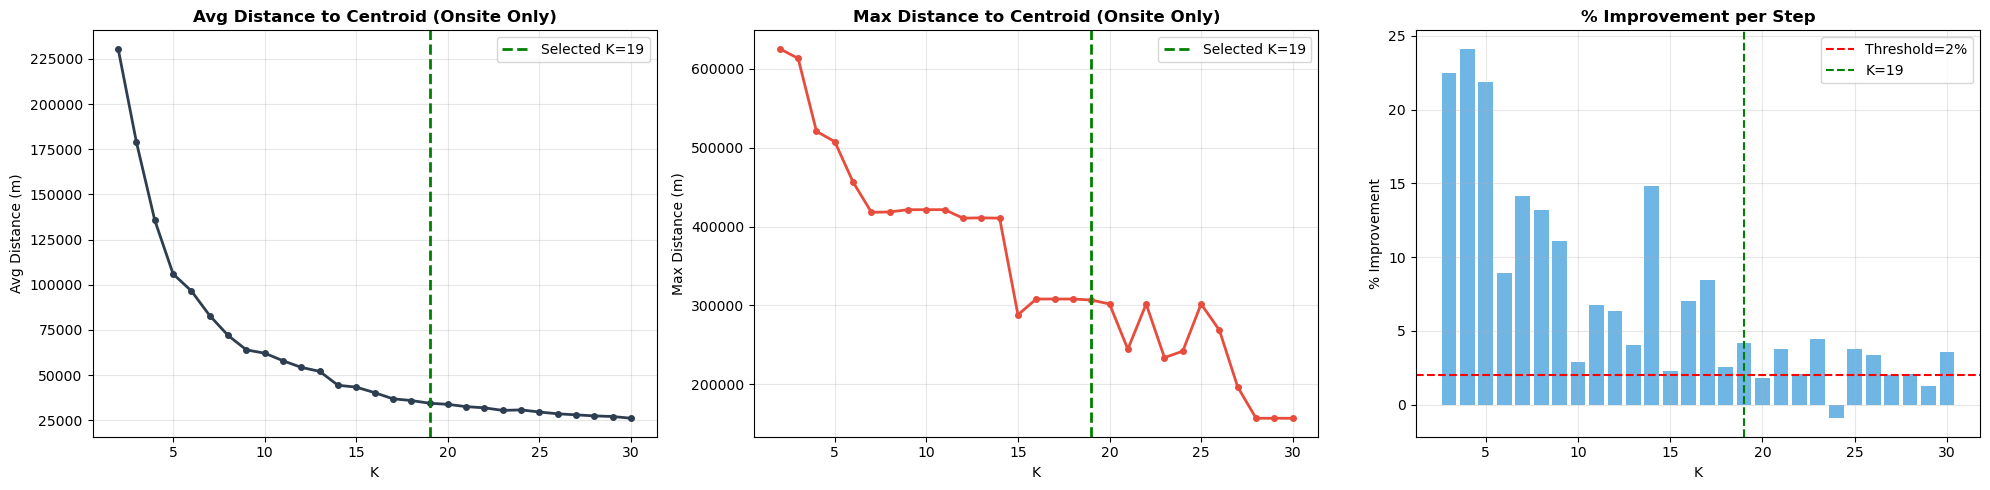

Saved: distance_analysis.png

Running final K-Means with K=19 on onsite claims only...
Onsite clustering complete.
Converting X/Y to Lat/Lon (EPSG:5070 -> WGS84)...
Conversion complete.
Applying feasibility-aware repair for onsite claims...

INITIAL CLUSTERING DIAGNOSTICS
  Total claims: 1062
  Onsite claims clustered: 848
  Online claims attached later: 214
  Onsite claims above 300 min threshold: 33
  Initial avg drive time (onsite): 83.3 min
  Initial max drive time (onsite): 744.6 min

FINAL CLUSTERING DIAGNOSTICS


,metric,value
0,total_claims,1062.000000
1,onsite_claims_clustered,848.000000
2,online_claims_attached,214.000000
3,initial_onsite_unreachable,33.000000
4,final_onsite_unreachable,0.000000
5,reassigned_existing_cluster,0.000000
6,assigned_secondary_cluster,33.000000
7,fallback_singleton_after_secondary,0.000000
8,new_isolated_singleton,0.000000
9,secondary_clusters_created,12.000000



SUCCESS: No onsite claims exceed the full-trip threshold after repair.



/tmp/ipykernel_3539234/631831588.py:534: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_colors)


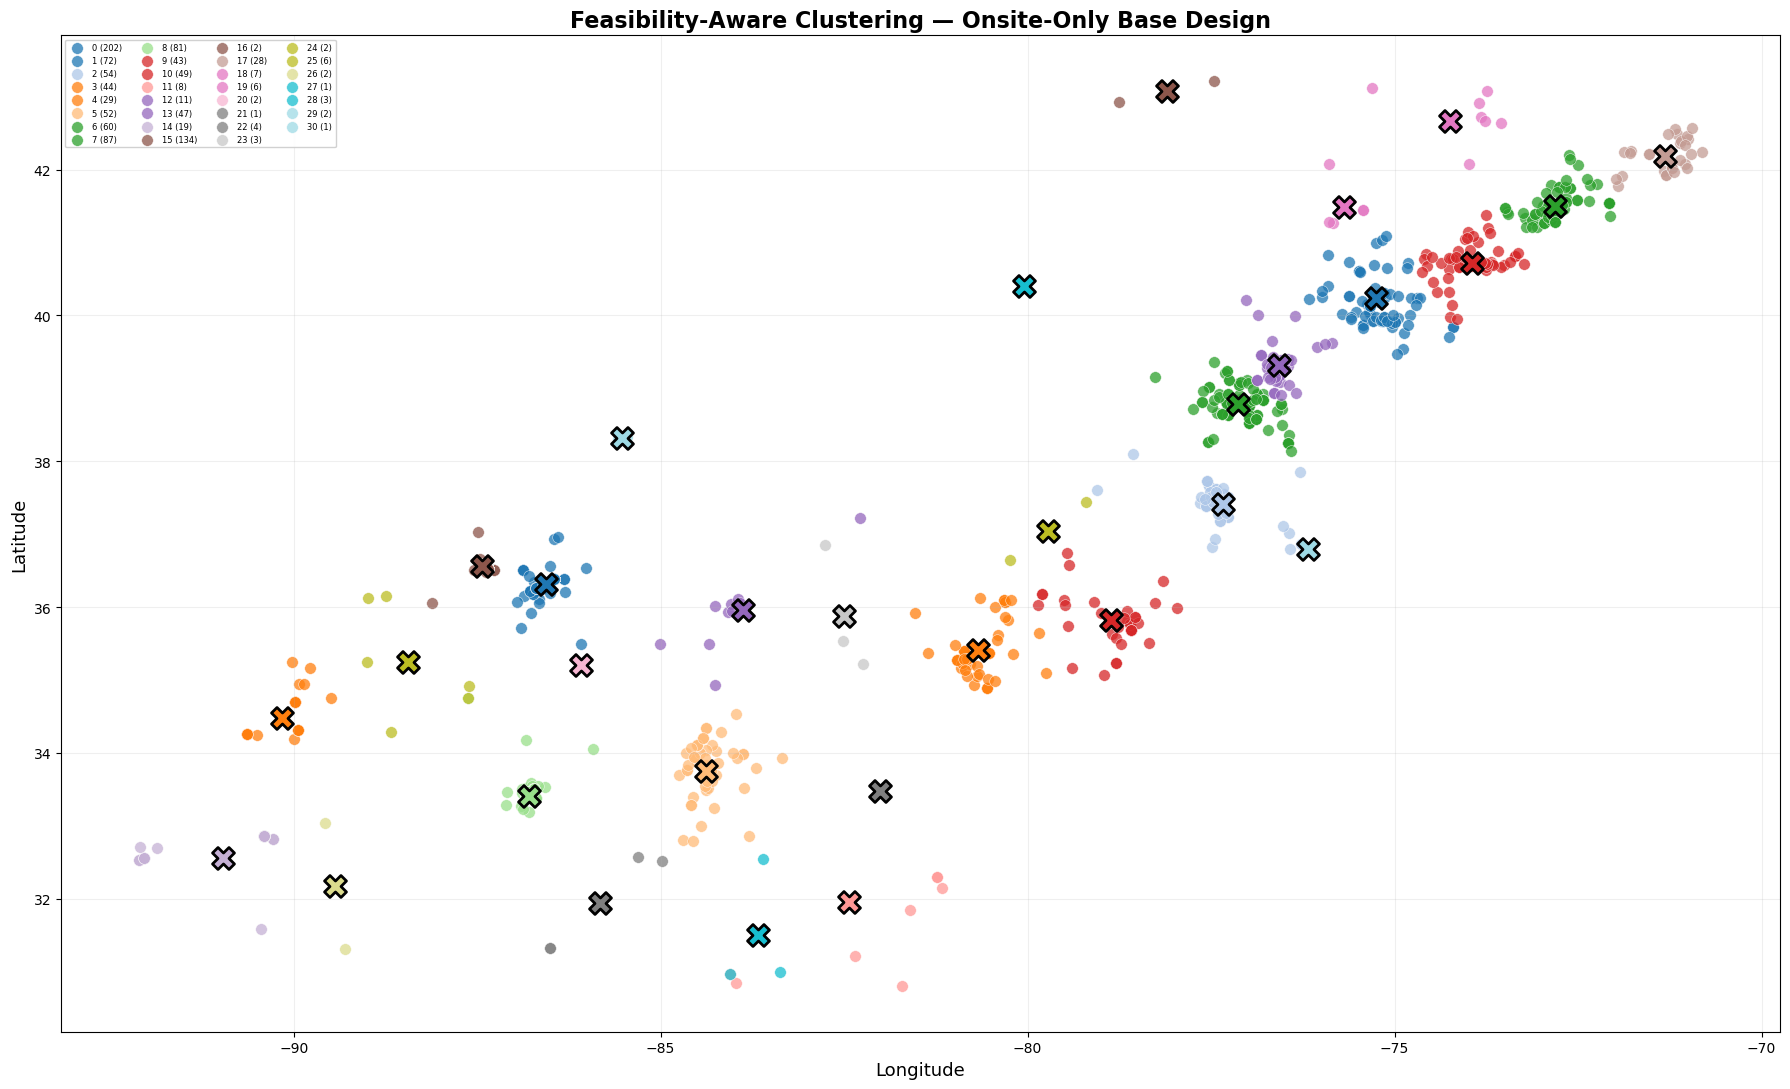

Saved: cluster_map_latlon_feasible.png

FINAL CLUSTER SUMMARY


,Cluster,cluster_type,Claims,Centroid_Lat,Centroid_Lon,Avg_Miles,Max_Miles,Avg_Drive_Min,Max_Drive_Min,Onsite_Claims,Online_Claims,Avg_Severity,Avg_SLA_Days
0,0,main,202,36.32,-86.56,8.40,62.79,32.75,244.89,140,62,3.04,20.20
1,1,main,72,40.23,-75.26,26.71,64.08,104.17,249.90,65,7,3.94,14.19
2,2,main,54,37.42,-77.34,20.51,94.75,80.00,369.52,47,7,3.87,14.91
3,3,main,44,35.41,-80.68,28.32,59.36,110.46,231.52,38,6,3.73,15.75
4,4,main,29,34.48,-90.17,28.48,54.14,111.06,211.13,20,9,3.00,20.76
5,5,main,52,33.75,-84.38,26.93,70.13,105.01,273.52,44,8,3.52,17.37
6,6,main,60,41.51,-72.82,21.06,49.17,82.12,191.78,56,4,3.83,15.17
7,7,main,87,38.79,-77.13,21.88,65.91,85.33,257.05,80,7,3.89,14.80
8,8,main,81,33.41,-86.79,8.15,104.85,31.77,408.92,56,25,3.22,18.84
9,9,main,43,35.82,-78.87,28.17,71.65,109.87,279.42,32,11,3.28,18.72



FINAL TIME-DISTANCE MATRIX


,Claim Number,Cluster,cluster_type,cluster_group,Claim_Lat,Claim_Lon,Centroid_Lat,Centroid_Lon,Straight_Line_Miles,Est_Road_Miles,Est_Drive_Time_Min,On-Site Handling,Virtual Handling,repair_status
524,46023767,0,main,0,36.3054,-86.6072,36.3176,-86.5608,2.72,7.06,10.6,False,True,online_attached_to_nearest_main
541,54470931,0,main,0,36.3054,-86.6072,36.3176,-86.5608,2.72,7.06,10.6,True,False,original
542,45346385,0,main,0,36.3054,-86.6072,36.3176,-86.5608,2.72,7.06,10.6,True,False,original
543,49946138,0,main,0,36.3054,-86.6072,36.3176,-86.5608,2.72,7.06,10.6,True,False,original
546,79916476,0,main,0,36.3054,-86.6072,36.3176,-86.5608,2.72,7.06,10.6,False,True,online_attached_to_nearest_main
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
801,33476502,0,main,0,36.3834,-86.4512,36.3176,-86.5608,7.61,19.78,29.7,False,True,online_attached_to_nearest_main
877,89095133,0,main,0,36.3834,-86.4512,36.3176,-86.5608,7.61,19.78,29.7,False,True,online_attached_to_nearest_main
893,92352574,0,main,0,36.3834,-86.4512,36.3176,-86.5608,7.61,19.78,29.7,True,False,original
894,75728900,0,main,0,36.3834,-86.4512,36.3176,-86.5608,7.61,19.78,29.7,True,False,original



Results exported to: Datasets/ds_claims_clustered.xlsx
  Sheet 1: Clustered Claims
  Sheet 2: Cluster Summary
  Sheet 3: Time-Distance Matrix
  Sheet 4: Repair Summary

Done!


In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pyproj import Transformer
from math import radians, sin, cos, sqrt, atan2

# CONFIGURATION

INPUT_FILE = "Datasets/ds_claim_optClean_projected.xlsx"
OUTPUT_FILE = "Datasets/ds_claims_clustered.xlsx"
SHEET_NAME = 0
X_COL = "X"
Y_COL = "Y"
MIN_K = 2
MAX_K = 30
IMPROVEMENT_THRESHOLD = 0.02  # Stop when avg distance improvement < 2%

# Projection: EPSG:5070 (NAD83 Conus Albers Equal Area Conic, meters)

PROJ_CRS = "EPSG:5070"
GEO_CRS  = "EPSG:4326"

# Drive time estimation
AVG_SPEED_MPH = 40

# Repair rules
MAX_FULL_TRIP_DRIVE_MIN = 300.0   # 5 hours round trip
ONSITE_COL = "On-Site Handling"
ONLINE_COL = "Virtual Handling"

MAIN_CLUSTER_TYPE = "main"
SECONDARY_CLUSTER_TYPE = "secondary"
SINGLETON_CLUSTER_TYPE = "isolated_singleton"

# HELPER FUNCTIONS

proj_to_geo = Transformer.from_crs(PROJ_CRS, GEO_CRS, always_xy=True)

def xy_to_latlon(x, y):
    lon, lat = proj_to_geo.transform(x, y)
    return lat, lon

def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

def compute_travel_metrics(claim_lat, claim_lon, centroid_lat, centroid_lon, avg_speed_mph=45):
    straight_line_miles = haversine_miles(claim_lat, claim_lon, centroid_lat, centroid_lon)

    # 2.6 factor = road inflation + return trip
    est_road_miles = straight_line_miles * 2.6
    est_drive_time_min = est_road_miles / avg_speed_mph * 60

    return straight_line_miles, est_road_miles, est_drive_time_min

def assign_cluster_fields_from_maps(df_in, centroid_maps, overwrite_cluster_type=False):
    out = df_in.copy()
    out["Centroid_X"] = out["Cluster"].map(lambda c: centroid_maps[c]["x"])
    out["Centroid_Y"] = out["Cluster"].map(lambda c: centroid_maps[c]["y"])
    out["Centroid_Lat"] = out["Cluster"].map(lambda c: centroid_maps[c]["lat"])
    out["Centroid_Lon"] = out["Cluster"].map(lambda c: centroid_maps[c]["lon"])
    if overwrite_cluster_type or "cluster_type" not in out.columns:
        out["cluster_type"] = out["Cluster"].map(lambda c: centroid_maps[c]["cluster_type"])
    return out

def nearest_main_cluster_id(x, y, centroid_maps):
    best_cluster = None
    best_dist = None
    for c, meta in centroid_maps.items():
        # only compare against current main clusters
        if meta["cluster_type"] != MAIN_CLUSTER_TYPE:
            continue
        dx = x - meta["x"]
        dy = y - meta["y"]
        dist2 = dx * dx + dy * dy
        if best_dist is None or dist2 < best_dist:
            best_dist = dist2
            best_cluster = c
    return int(best_cluster)

# STEP 1:

print("Reading data from:", INPUT_FILE)
df = pd.read_excel(INPUT_FILE, sheet_name=SHEET_NAME)
print(f"Loaded {len(df)} records with {len(df.columns)} columns")
print(f"Columns found: {list(df.columns)}\n")

if X_COL not in df.columns or Y_COL not in df.columns:
    raise ValueError(f"Columns '{X_COL}' and/or '{Y_COL}' not found.\nAvailable: {list(df.columns)}")

before = len(df)
df = df.dropna(subset=[X_COL, Y_COL]).copy()
if len(df) < before:
    print(f"Dropped {before - len(df)} rows with missing X/Y values")

if ONSITE_COL not in df.columns:
    raise ValueError(f"Expected column '{ONSITE_COL}' not found in clustering input.")

# Split datasets
df_onsite = df[df[ONSITE_COL] == True].copy()
df_online = df[df[ONSITE_COL] != True].copy()

if len(df_onsite) == 0:
    raise ValueError("No onsite claims found. Clustering cannot be built.")

coords_onsite = df_onsite[[X_COL, Y_COL]].values

# STEP 2: Evaluate K for Compactness (ONSITE ONLY)

print(f"Evaluating K={MIN_K} to K={MAX_K} for maximum compactness on onsite claims only...")
print(f"Stopping when improvement < {IMPROVEMENT_THRESHOLD*100:.0f}% per step\n")

K_range = list(range(MIN_K, MAX_K + 1))
avg_distances = []
max_distances = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(coords_onsite)
    dists = np.sqrt(np.sum((coords_onsite - km.cluster_centers_[labels]) ** 2, axis=1))
    avg_distances.append(np.mean(dists))
    max_distances.append(np.max(dists))
    print(f"  K={k:>2d}  AvgDist={np.mean(dists):>12,.2f}  MaxDist={np.max(dists):>12,.2f}")

best_k = K_range[0]
for i in range(1, len(K_range)):
    pct_improvement = (avg_distances[i - 1] - avg_distances[i]) / avg_distances[i - 1]
    if pct_improvement < IMPROVEMENT_THRESHOLD:
        best_k = K_range[i - 1]
        break
else:
    best_k = K_range[-1]

best_idx = K_range.index(best_k)
print(f"\n>>> Selected K = {best_k}")
print(f"    Avg distance to centroid: {avg_distances[best_idx]:,.2f} meters")
print(f"    Max distance to centroid: {max_distances[best_idx]:,.2f} meters")
print(f"    Avg onsite claims per cluster:   {len(df_onsite) / best_k:.1f}\n")

# STEP 3: Distance Analysis Plots

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(K_range, avg_distances, "o-", color="#2c3e50", linewidth=2, markersize=4)
axes[0].axvline(x=best_k, color="green", linestyle="--", linewidth=2, label=f"Selected K={best_k}")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Avg Distance (m)")
axes[0].set_title("Avg Distance to Centroid (Onsite Only)", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, max_distances, "o-", color="#e74c3c", linewidth=2, markersize=4)
axes[1].axvline(x=best_k, color="green", linestyle="--", linewidth=2, label=f"Selected K={best_k}")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Max Distance (m)")
axes[1].set_title("Max Distance to Centroid (Onsite Only)", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

pct_imp = [(avg_distances[i - 1] - avg_distances[i]) / avg_distances[i - 1] * 100 for i in range(1, len(avg_distances))]
axes[2].bar(K_range[1:], pct_imp, color="#3498db", alpha=0.7)
axes[2].axhline(y=IMPROVEMENT_THRESHOLD * 100, color="red", linestyle="--", label=f"Threshold={IMPROVEMENT_THRESHOLD*100:.0f}%")
axes[2].axvline(x=best_k, color="green", linestyle="--", label=f"K={best_k}")
axes[2].set_xlabel("K")
axes[2].set_ylabel("% Improvement")
axes[2].set_title("% Improvement per Step", fontweight="bold")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("distance_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: distance_analysis.png")

# STEP 4: Final Clustering (ONSITE ONLY)

print(f"\nRunning final K-Means with K={best_k} on onsite claims only...")
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)

df_onsite["Cluster"] = kmeans.fit_predict(coords_onsite).astype(int)
df_onsite["Cluster"] = df_onsite["Cluster"].astype(object)
df_onsite["cluster_type"] = MAIN_CLUSTER_TYPE
df_onsite["cluster_group"] = df_onsite["Cluster"]

centroids = kmeans.cluster_centers_
print("Onsite clustering complete.")

# STEP 5: Convert X/Y and Centroids to Lat/Lon

print("Converting X/Y to Lat/Lon (EPSG:5070 -> WGS84)...")

centroid_latlon = np.array([xy_to_latlon(c[0], c[1]) for c in centroids])

centroid_maps = {}
for i in range(best_k):
    centroid_maps[int(i)] = {
        "x": float(centroids[i, 0]),
        "y": float(centroids[i, 1]),
        "lat": float(centroid_latlon[i, 0]),
        "lon": float(centroid_latlon[i, 1]),
        "cluster_type": MAIN_CLUSTER_TYPE,
    }

# Claim lat/lon
for subset_name, subset in [("onsite", df_onsite), ("online", df_online)]:
    if len(subset) == 0:
        continue
    if "Lat" in subset.columns and "Lon" in subset.columns:
        subset["Claim_Lat"] = subset["Lat"]
        subset["Claim_Lon"] = subset["Lon"]
    else:
        latlon = np.array([xy_to_latlon(r[X_COL], r[Y_COL]) for _, r in subset.iterrows()])
        subset["Claim_Lat"] = latlon[:, 0]
        subset["Claim_Lon"] = latlon[:, 1]

# Onsite gets fitted cluster fields
df_onsite = assign_cluster_fields_from_maps(df_onsite, centroid_maps, overwrite_cluster_type=True)

# Online gets nearest main cluster only for reporting consistency
if len(df_online) > 0:
    df_online["Cluster"] = df_online.apply(
        lambda r: nearest_main_cluster_id(r[X_COL], r[Y_COL], centroid_maps),
        axis=1
    ).astype(object)

    df_online["cluster_group"] = df_online["Cluster"]
    # let cluster_type come from the cluster itself
    df_online = assign_cluster_fields_from_maps(df_online, centroid_maps, overwrite_cluster_type=True)

    df_online = assign_cluster_fields_from_maps(df_online, centroid_maps, overwrite_cluster_type=False)

print("Conversion complete.")

# STEP 6: FEASIBILITY-AWARE CLUSTER REPAIR (ONSITE ONLY)

print("Applying feasibility-aware repair for onsite claims...\n")

travel_metrics = df_onsite.apply(
    lambda r: compute_travel_metrics(
        r["Claim_Lat"], r["Claim_Lon"],
        r["Centroid_Lat"], r["Centroid_Lon"],
        AVG_SPEED_MPH
    ),
    axis=1
)

df_onsite["Straight_Line_Miles"] = [t[0] for t in travel_metrics]
df_onsite["Est_Road_Miles"] = [t[1] for t in travel_metrics]
df_onsite["Est_Drive_Time_Min"] = [t[2] for t in travel_metrics]
df_onsite["repair_status"] = "original"

initial_onsite = df_onsite.copy()
initial_unreachable = initial_onsite[initial_onsite["Est_Drive_Time_Min"] >= MAX_FULL_TRIP_DRIVE_MIN].copy()

print("INITIAL CLUSTERING DIAGNOSTICS")
print(f"  Total claims: {len(df)}")
print(f"  Onsite claims clustered: {len(df_onsite)}")
print(f"  Online claims attached later: {len(df_online)}")
print(f"  Onsite claims above {MAX_FULL_TRIP_DRIVE_MIN:.0f} min threshold: {len(initial_unreachable)}")
print(f"  Initial avg drive time (onsite): {df_onsite['Est_Drive_Time_Min'].mean():.1f} min")
print(f"  Initial max drive time (onsite): {df_onsite['Est_Drive_Time_Min'].max():.1f} min\n")

main_cluster_ids = sorted([int(c) for c in centroid_maps.keys()])
next_cluster_id = max(main_cluster_ids) + 1
outlier_rows = []

# Pass 1: try reassigning unreachable onsite claims to a better main cluster
for idx, row in df_onsite.iterrows():
    if row["Est_Drive_Time_Min"] < MAX_FULL_TRIP_DRIVE_MIN:
        continue

    claim_lat = row["Claim_Lat"]
    claim_lon = row["Claim_Lon"]

    best_cluster = None
    best_metrics = None

    for c in main_cluster_ids:
        c_lat = centroid_maps[c]["lat"]
        c_lon = centroid_maps[c]["lon"]

        sl_mi, road_mi, drive_min = compute_travel_metrics(
            claim_lat, claim_lon, c_lat, c_lon, AVG_SPEED_MPH
        )

        if best_metrics is None or drive_min < best_metrics[2]:
            best_cluster = c
            best_metrics = (sl_mi, road_mi, drive_min)

    if best_metrics is not None and best_metrics[2] < MAX_FULL_TRIP_DRIVE_MIN:
        df_onsite.at[idx, "Cluster"] = int(best_cluster)
        df_onsite.at[idx, "Centroid_X"] = centroid_maps[best_cluster]["x"]
        df_onsite.at[idx, "Centroid_Y"] = centroid_maps[best_cluster]["y"]
        df_onsite.at[idx, "Centroid_Lat"] = centroid_maps[best_cluster]["lat"]
        df_onsite.at[idx, "Centroid_Lon"] = centroid_maps[best_cluster]["lon"]
        df_onsite.at[idx, "Straight_Line_Miles"] = best_metrics[0]
        df_onsite.at[idx, "Est_Road_Miles"] = best_metrics[1]
        df_onsite.at[idx, "Est_Drive_Time_Min"] = best_metrics[2]
        df_onsite.at[idx, "cluster_type"] = MAIN_CLUSTER_TYPE
        df_onsite.at[idx, "repair_status"] = "reassigned_existing_cluster"
    else:
        outlier_rows.append(idx)

secondary_created = 0
secondary_members_total = 0

# Pass 2: cluster remaining outliers into secondary clusters
if len(outlier_rows) > 0:
    outlier_df = df_onsite.loc[outlier_rows].copy()
    outlier_coords = outlier_df[[X_COL, Y_COL]].values

    best_outlier_labels = None
    best_outlier_centers = None
    max_k_outlier = len(outlier_df)

    for k_out in range(1, max_k_outlier + 1):
        km_out = KMeans(n_clusters=k_out, random_state=42, n_init=10)
        labels_out = km_out.fit_predict(outlier_coords)
        centers_out = km_out.cluster_centers_

        tmp = outlier_df.copy()
        tmp["_sec_label"] = labels_out

        tmp_center_latlon = {
            lab: xy_to_latlon(centers_out[lab, 0], centers_out[lab, 1])
            for lab in range(k_out)
        }

        tmp_drive_ok = []
        for _, r in tmp.iterrows():
            sec_lab = r["_sec_label"]
            sec_lat, sec_lon = tmp_center_latlon[sec_lab]
            _, _, drive_min = compute_travel_metrics(
                r["Claim_Lat"], r["Claim_Lon"],
                sec_lat, sec_lon,
                AVG_SPEED_MPH
            )
            tmp_drive_ok.append(drive_min < MAX_FULL_TRIP_DRIVE_MIN)

        tmp["_sec_drive_ok"] = tmp_drive_ok

        if tmp["_sec_drive_ok"].all():
            best_outlier_labels = labels_out
            best_outlier_centers = centers_out
            break

    if best_outlier_labels is not None:
        outlier_df["_sec_label"] = best_outlier_labels

        for sec_lab in sorted(outlier_df["_sec_label"].unique()):
            sec_members = outlier_df[outlier_df["_sec_label"] == sec_lab].copy()

            sec_id = int(next_cluster_id)
            next_cluster_id += 1

            sec_x = float(best_outlier_centers[sec_lab, 0])
            sec_y = float(best_outlier_centers[sec_lab, 1])
            sec_lat, sec_lon = xy_to_latlon(sec_x, sec_y)

            centroid_maps[sec_id] = {
                "x": sec_x,
                "y": sec_y,
                "lat": float(sec_lat),
                "lon": float(sec_lon),
                "cluster_type": SECONDARY_CLUSTER_TYPE,
            }

            secondary_created += 1
            secondary_members_total += len(sec_members)

            for sec_idx, sec_row in sec_members.iterrows():
                sl_mi, road_mi, drive_min = compute_travel_metrics(
                    sec_row["Claim_Lat"], sec_row["Claim_Lon"],
                    sec_lat, sec_lon,
                    AVG_SPEED_MPH
                )

                if drive_min >= MAX_FULL_TRIP_DRIVE_MIN:
                    iso_id = int(next_cluster_id)
                    next_cluster_id += 1

                    centroid_maps[iso_id] = {
                        "x": float(sec_row[X_COL]),
                        "y": float(sec_row[Y_COL]),
                        "lat": float(sec_row["Claim_Lat"]),
                        "lon": float(sec_row["Claim_Lon"]),
                        "cluster_type": SINGLETON_CLUSTER_TYPE,
                    }

                    df_onsite.at[sec_idx, "Cluster"] = iso_id
                    df_onsite.at[sec_idx, "Centroid_X"] = sec_row[X_COL]
                    df_onsite.at[sec_idx, "Centroid_Y"] = sec_row[Y_COL]
                    df_onsite.at[sec_idx, "Centroid_Lat"] = sec_row["Claim_Lat"]
                    df_onsite.at[sec_idx, "Centroid_Lon"] = sec_row["Claim_Lon"]
                    df_onsite.at[sec_idx, "Straight_Line_Miles"] = 0.0
                    df_onsite.at[sec_idx, "Est_Road_Miles"] = 0.0
                    df_onsite.at[sec_idx, "Est_Drive_Time_Min"] = 0.0
                    df_onsite.at[sec_idx, "cluster_type"] = SINGLETON_CLUSTER_TYPE
                    df_onsite.at[sec_idx, "cluster_group"] = sec_row["cluster_group"]
                    df_onsite.at[sec_idx, "repair_status"] = "fallback_singleton_after_secondary"
                else:
                    df_onsite.at[sec_idx, "Cluster"] = sec_id
                    df_onsite.at[sec_idx, "Centroid_X"] = sec_x
                    df_onsite.at[sec_idx, "Centroid_Y"] = sec_y
                    df_onsite.at[sec_idx, "Centroid_Lat"] = sec_lat
                    df_onsite.at[sec_idx, "Centroid_Lon"] = sec_lon
                    df_onsite.at[sec_idx, "Straight_Line_Miles"] = sl_mi
                    df_onsite.at[sec_idx, "Est_Road_Miles"] = road_mi
                    df_onsite.at[sec_idx, "Est_Drive_Time_Min"] = drive_min
                    df_onsite.at[sec_idx, "cluster_type"] = SECONDARY_CLUSTER_TYPE
                    df_onsite.at[sec_idx, "cluster_group"] = sec_row["cluster_group"]
                    df_onsite.at[sec_idx, "repair_status"] = "assigned_secondary_cluster"
    else:
        for idx in outlier_rows:
            row = df_onsite.loc[idx]

            iso_id = int(next_cluster_id)
            next_cluster_id += 1

            centroid_maps[iso_id] = {
                "x": float(row[X_COL]),
                "y": float(row[Y_COL]),
                "lat": float(row["Claim_Lat"]),
                "lon": float(row["Claim_Lon"]),
                "cluster_type": SINGLETON_CLUSTER_TYPE,
            }

            df_onsite.at[idx, "Cluster"] = iso_id
            df_onsite.at[idx, "Centroid_X"] = row[X_COL]
            df_onsite.at[idx, "Centroid_Y"] = row[Y_COL]
            df_onsite.at[idx, "Centroid_Lat"] = row["Claim_Lat"]
            df_onsite.at[idx, "Centroid_Lon"] = row["Claim_Lon"]
            df_onsite.at[idx, "Straight_Line_Miles"] = 0.0
            df_onsite.at[idx, "Est_Road_Miles"] = 0.0
            df_onsite.at[idx, "Est_Drive_Time_Min"] = 0.0
            df_onsite.at[idx, "cluster_type"] = SINGLETON_CLUSTER_TYPE
            df_onsite.at[idx, "cluster_group"] = row["cluster_group"]
            df_onsite.at[idx, "repair_status"] = "new_isolated_singleton"

final_onsite = df_onsite.copy()
final_unreachable = final_onsite[final_onsite["Est_Drive_Time_Min"] >= MAX_FULL_TRIP_DRIVE_MIN].copy()

# Online claims: assign travel metrics after onsite repair is complete
if len(df_online) > 0:
    online_travel_metrics = df_online.apply(
        lambda r: compute_travel_metrics(
            r["Claim_Lat"], r["Claim_Lon"],
            r["Centroid_Lat"], r["Centroid_Lon"],
            AVG_SPEED_MPH
        ),
        axis=1
    )

    df_online["Straight_Line_Miles"] = [t[0] for t in online_travel_metrics]
    df_online["Est_Road_Miles"] = [t[1] for t in online_travel_metrics]
    df_online["Est_Drive_Time_Min"] = [t[2] for t in online_travel_metrics]
    df_online["repair_status"] = "online_attached_to_nearest_main"

repair_summary = pd.DataFrame({
    "metric": [
        "total_claims",
        "onsite_claims_clustered",
        "online_claims_attached",
        "initial_onsite_unreachable",
        "final_onsite_unreachable",
        "reassigned_existing_cluster",
        "assigned_secondary_cluster",
        "fallback_singleton_after_secondary",
        "new_isolated_singleton",
        "secondary_clusters_created",
        "secondary_cluster_members_total",
        "final_avg_drive_time_onsite",
        "final_max_drive_time_onsite"
    ],
    "value": [
        len(df),
        len(df_onsite),
        len(df_online),
        len(initial_unreachable),
        len(final_unreachable),
        int((df_onsite["repair_status"] == "reassigned_existing_cluster").sum()),
        int((df_onsite["repair_status"] == "assigned_secondary_cluster").sum()),
        int((df_onsite["repair_status"] == "fallback_singleton_after_secondary").sum()),
        int((df_onsite["repair_status"] == "new_isolated_singleton").sum()),
        secondary_created,
        secondary_members_total,
        float(final_onsite["Est_Drive_Time_Min"].mean()) if len(final_onsite) > 0 else np.nan,
        float(final_onsite["Est_Drive_Time_Min"].max()) if len(final_onsite) > 0 else np.nan,
    ]
})

print("FINAL CLUSTERING DIAGNOSTICS")
display(repair_summary)

if len(final_unreachable) > 0:
    print("\nWARNING: Some onsite claims still exceed threshold after repair.")
    display(final_unreachable[[
        "Claim Number", "Cluster", "cluster_type", "cluster_group",
        "Est_Drive_Time_Min", "Claim_Lat", "Claim_Lon"
    ]].head(50))
else:
    print("\nSUCCESS: No onsite claims exceed the full-trip threshold after repair.\n")

# Recombine for reporting
df = pd.concat([df_onsite, df_online], axis=0).sort_index().copy()

# STEP 7: FINAL CLUSTER MAP (LAT/LON)

cluster_ids_sorted = sorted(centroid_maps.keys())

n_colors = max(len(cluster_ids_sorted), 20)
cmap = cm.get_cmap("tab20", n_colors)
cluster_color_map = {cid: cmap(i % n_colors) for i, cid in enumerate(cluster_ids_sorted)}

fig, ax = plt.subplots(figsize=(18, 11))

for cid in cluster_ids_sorted:
    mask = df["Cluster"] == cid
    cluster_df = df[mask]
    color = cluster_color_map[cid]

    ax.scatter(
        cluster_df["Claim_Lon"], cluster_df["Claim_Lat"],
        c=[color], s=70, alpha=0.75, edgecolors="white", linewidth=0.4,
        label=f"{cid} ({mask.sum()})"
    )

    ax.scatter(
        centroid_maps[cid]["lon"], centroid_maps[cid]["lat"],
        c=[color], s=250, marker="X", edgecolors="black", linewidth=2, zorder=5
    )

ax.set_xlabel("Longitude", fontsize=13)
ax.set_ylabel("Latitude", fontsize=13)
ax.set_title("Feasibility-Aware Clustering — Onsite-Only Base Design", fontsize=16, fontweight="bold")
ax.legend(fontsize=6, loc="best", framealpha=0.9, ncol=4)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("cluster_map_latlon_feasible.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: cluster_map_latlon_feasible.png")

# STEP 8: FINAL CLUSTER SUMMARY

summary = df.groupby("Cluster").agg(
    cluster_type=("cluster_type", "first"),
    Claims=("Cluster", "count"),
    Centroid_Lat=("Centroid_Lat", "first"),
    Centroid_Lon=("Centroid_Lon", "first"),
    Avg_Miles=("Straight_Line_Miles", "mean"),
    Max_Miles=("Straight_Line_Miles", "max"),
    Avg_Drive_Min=("Est_Drive_Time_Min", "mean"),
    Max_Drive_Min=("Est_Drive_Time_Min", "max"),
    Onsite_Claims=(ONSITE_COL, lambda s: int((s == True).sum())),
    Online_Claims=(ONLINE_COL, lambda s: int((s == True).sum())),
).reset_index()

if "CAT Severity Code" in df.columns:
    sev = df.groupby("Cluster")["CAT Severity Code"].mean().reset_index(name="Avg_Severity")
    summary = summary.merge(sev, on="Cluster", how="left")

if "SLA Days" in df.columns:
    sla = df.groupby("Cluster")["SLA Days"].mean().reset_index(name="Avg_SLA_Days")
    summary = summary.merge(sla, on="Cluster", how="left")

summary = summary.round(2)

print("\nFINAL CLUSTER SUMMARY")
display(summary)

# STEP 9: FINAL TIME-DISTANCE MATRIX

matrix = df[[
    "Claim Number", "Cluster", "cluster_type", "cluster_group",
    "Claim_Lat", "Claim_Lon",
    "Centroid_Lat", "Centroid_Lon",
    "Straight_Line_Miles", "Est_Road_Miles", "Est_Drive_Time_Min",
    ONSITE_COL, ONLINE_COL, "repair_status"
]].copy()

matrix = matrix.sort_values(["cluster_type", "Cluster", "Est_Drive_Time_Min"])
matrix["Straight_Line_Miles"] = matrix["Straight_Line_Miles"].round(2)
matrix["Est_Road_Miles"] = matrix["Est_Road_Miles"].round(2)
matrix["Est_Drive_Time_Min"] = matrix["Est_Drive_Time_Min"].round(1)
matrix["Claim_Lat"] = matrix["Claim_Lat"].round(4)
matrix["Claim_Lon"] = matrix["Claim_Lon"].round(4)
matrix["Centroid_Lat"] = matrix["Centroid_Lat"].round(4)
matrix["Centroid_Lon"] = matrix["Centroid_Lon"].round(4)

print("\nFINAL TIME-DISTANCE MATRIX")
display(matrix.head(100))

# ║  STEP 10: EXPORT

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Clustered Claims", index=False)
    summary.to_excel(writer, sheet_name="Cluster Summary", index=False)
    matrix.to_excel(writer, sheet_name="Time-Distance Matrix", index=False)
    repair_summary.to_excel(writer, sheet_name="Repair Summary", index=False)

print(f"\nResults exported to: {OUTPUT_FILE}")
print("  Sheet 1: Clustered Claims")
print("  Sheet 2: Cluster Summary")
print("  Sheet 3: Time-Distance Matrix")
print("  Sheet 4: Repair Summary")
print("\nDone!")